# Convolutional Neural Network (CNN) for Image Classification on MNIST CSV Dataset By Abbas Rahem Abdulhamza

In this notebook, we will build a complete **Convolutional Neural Network (CNN)** to classify handwritten digit images from the **MNIST dataset**.

The dataset is provided in **CSV format**, which means each image is stored as a row of numbers:
- The first column is the **label** (digit 0 to 9)
- The remaining 784 columns are the **pixel values**
- Each image is **28 × 28** pixels
- Since 28 × 28 = 784, each image is flattened into one row

---

## What we will learn in this notebook

We will cover both the **theory** and the **implementation** of CNNs, including:

1. What image classification is
2. Why CNNs are better than ordinary neural networks for images
3. What convolution means
4. What filters/kernels do
5. What feature maps are
6. What activation functions do
7. What pooling layers do
8. Why flattening is needed
9. How dense layers perform final classification
10. How softmax converts outputs into probabilities
11. How model training works
12. How to evaluate a CNN using accuracy, loss, confusion matrix, and prediction visualization

---

## Why use CNN instead of a fully connected neural network?

A regular neural network treats each pixel independently after flattening the image into a vector.

A CNN is better for images because it:
- Preserves spatial structure
- Detects local patterns such as edges and curves
- Learns useful hierarchical features automatically
- Uses fewer parameters than a very large fully connected network
- Performs much better on image tasks

---

## CNN pipeline in simple words

A CNN usually works like this:

**Input Image → Convolution → Activation → Pooling → Convolution → Activation → Pooling → Flatten → Dense Layers → Output Classes**

---

## Dataset used

We will use the dataset:

`oddrationale/mnist-in-csv`

Downloaded with:

```python
import kagglehub
path = kagglehub.dataset_download("oddrationale/mnist-in-csv")

In [141]:

# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import Sequential, regularizers


from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical
# Evaluation
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Step 1: Load the skin data

In [116]:
''' Kaggle download, do not uncomment unless you really dont have the data xD
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sha2048/minecraft-skin-dataset") # Attention, this dataset has a size of > 1.8 GB

print("Path to dataset files:", path)
print("Files inside dataset folder:", os.listdir(path))
'''

' Kaggle download, do not uncomment unless you really dont have the data xD\nimport kagglehub\n\n# Download latest version\npath = kagglehub.dataset_download("sha2048/minecraft-skin-dataset") # Attention, this dataset has a size of > 1.8 GB\n\nprint("Path to dataset files:", path)\nprint("Files inside dataset folder:", os.listdir(path))\n'

In [117]:
root_path = Path('./../data/skins/')
normal_dir = root_path / "good"
bad_dir = root_path / "bad" / "spiderman" # TODO make more dynamic

In [118]:
seed = 67
rng = np.random.default_rng(seed)

In [119]:
def sample_images(folder: Path, n: int):
    pattern = "*.png"
    files = [p for p in folder.glob(pattern) if p.is_file()]
    #print(files)
    if len(files) < n:
        raise ValueError(f"Not enough PNG files in {folder}. Found {len(files)}, need {n}.")
    idxs = rng.choice(len(files), size=n, replace=False)
    return [files[i] for i in idxs]

normal_file_paths = sample_images(normal_dir, 1000)
bad_file_paths = sample_images(bad_dir, 1000)

In [120]:
# label (y)
y = np.array([0] * len(normal_file_paths) + [1] * len(bad_file_paths)) # 0 = normal, 1 = bad

# shuffle
all_files = normal_file_paths + bad_file_paths
permutated_indices = rng.permutation(len(all_files))
all_files = np.array(all_files, dtype=object)[permutated_indices] # shuffle x
y = y[permutated_indices]

In [121]:
df = pd.DataFrame({"path": all_files, "label": y})
print("Total:", len(df))
print("Class counts [normal,bad]:", np.bincount(y))
df.head()

Total: 2000
Class counts [normal,bad]: [1000 1000]


,path,label
0,..\data\skins\good\0c3373d0093040d3a7fcb187554...,0
1,..\data\skins\bad\spiderman\spiderman_22088249...,1
2,..\data\skins\bad\spiderman\spiderman_21897216...,1
3,..\data\skins\bad\spiderman\spiderman_21674090...,1
4,..\data\skins\bad\spiderman\spiderman_22347772...,1


In [122]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_rgba(path):
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_png(img_bytes, channels=4)
    img = tf.image.resize(img, IMG_SIZE, method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    img = tf.cast(img, tf.float32) / 255.0
    return img

images = [load_rgba(str(image)) for image in all_files]

In [123]:
print(images[0])

tf.Tensor(
[[[0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  ...
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]]

 [[0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  ...
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]]

 [[0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  ...
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]]

 ...

 [[0.3529412  0.10196079 0.12156863 1.        ]
  [0.         0.         0.         0.        ]

In [124]:
# -----------------------------
# 1) Train / Val / Test split
# -----------------------------
# 80% train_val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    images, y,
    test_size=0.20,
    random_state=seed,
    stratify=y
)

# From train_val: 80% train, 20% val  -> final: 64/16/20
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.20,
    random_state=seed,
    stratify=y_trainval
)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))
print("Train class counts:", np.bincount(y_train))
print("Val class counts:", np.bincount(y_val))
print("Test class counts:", np.bincount(y_test))

# shapes
print(X_train[0])
print(y_train[0])

Train: 1280 Val: 320 Test: 400
Train class counts: [640 640]
Val class counts: [160 160]
Test class counts: [200 200]
tf.Tensor(
[[[0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  ...
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]]

 [[0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  ...
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]]

 [[0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  ...
  [0.         0.         0.         0.        ]
  [0.         0.         0.         0.        ]
  [0.         0.         0.      

In [125]:
# Convert list-of-tensors -> single batched tensor
X_train = tf.stack(X_train)  # (1280, 64, 64, 4)
X_val   = tf.stack(X_val)    # (320, 64, 64, 4) if your split is 64/16/20
X_test  = tf.stack(X_test)

# Ensure labels are plain numeric vectors
y_train = np.asarray(y_train, dtype=np.float32)
y_val   = np.asarray(y_val, dtype=np.float32)
y_test  = np.asarray(y_test, dtype=np.float32)

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)

X_train: (1280, 64, 64, 4) <dtype: 'float32'>
y_train: (1280,) float32


## Step 7: Visualize some sample images

Before training, it is always useful to inspect the dataset visually.

This helps confirm:
- the images loaded correctly
- labels match the images
- reshaping was successful

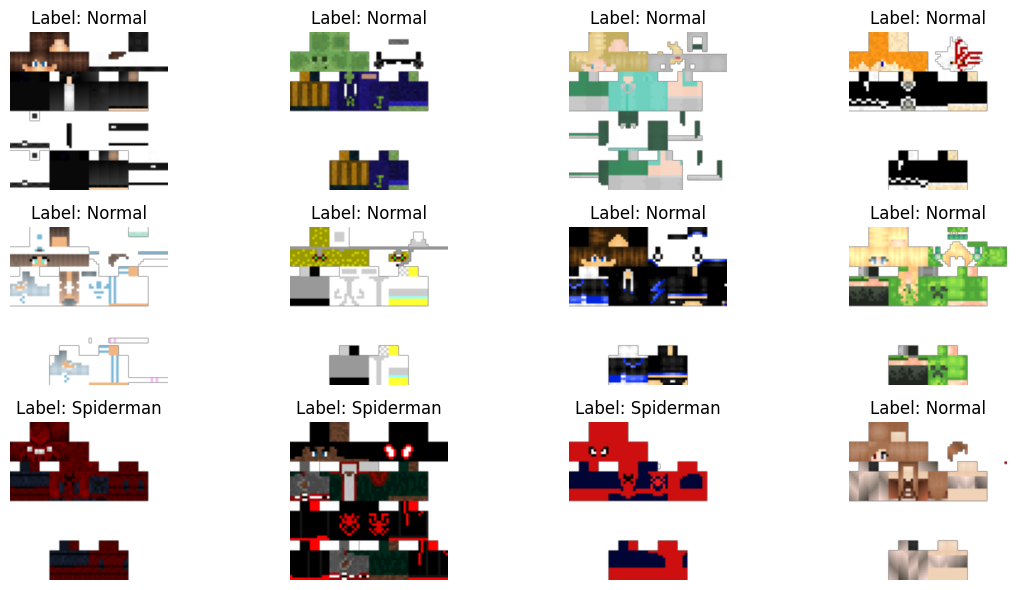

In [126]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i])
    plt.title(f"Label: {('Spiderman' if (y_train[i] == 1) else 'Normal')}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 8: Understand CNN layers

Before building the model, let us understand the key CNN components.

### 1. Convolution Layer
A convolution layer uses small filters (also called kernels) that slide over the image.

Each filter learns to detect useful patterns such as:
- edges
- corners
- curves
- strokes
- texture-like structures

For example:
- one filter may detect vertical edges
- another may detect horizontal edges
- another may detect curved shapes

The output of a convolution is called a **feature map**.

---

### 2. Activation Function
After convolution, we apply an activation function such as **ReLU**.

ReLU means:

\[
ReLU(x) = max(0, x)
\]

This makes the network non-linear and helps it learn complex patterns.

---

### 3. Pooling Layer
Pooling reduces the spatial size of the feature maps.

The most common type is **Max Pooling**.

It keeps the strongest value in a small window such as 2 × 2.

Benefits:
- reduces computation
- reduces overfitting
- keeps important features
- makes the network somewhat robust to small position changes

---

### 4. Flatten Layer
After convolution and pooling, the feature maps are flattened into a 1D vector.

This allows us to connect them to dense layers for final classification.

---

### 5. Dense Layers
Dense layers act like the classifier part of the CNN.

They use the extracted features to decide which digit the image belongs to.

---

### 6. Softmax Output
The final layer has 10 neurons, one for each class.

Softmax converts the outputs into probabilities that sum to 1.

The predicted class is the one with the highest probability.

## Step 9: Build the CNN model

We will create a practical CNN architecture:

- Conv2D
- Batch Normalization
- MaxPooling
- Conv2D
- Batch Normalization
- MaxPooling
- Flatten
- Dense
- Dropout
- Output layer with Softmax

### Why Batch Normalization?
It helps training become more stable and often speeds up convergence.

### Why Dropout?
It randomly disables some neurons during training to reduce overfitting.

In [145]:
model = Sequential([
    Input(shape=(64, 64, 4)),

    Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.15),

    Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.20),

    Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),

    GlobalAveragePooling2D(),
    Dense(64, activation="relu"),
    Dropout(0.40),
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 64, 64, 32)     │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,313 (583.25 KB)

 Trainable params: 148,673 (580.75 KB)

 Non-trainable params: 640 (2.50 KB)

## Step 10: Compile the model

To train a neural network, we must define:

### 1. Optimizer
We will use **Adam**, which is a popular and effective optimization algorithm.

### 2. Loss function
Because this is a multi-class classification problem with one-hot encoded labels, we use:

**categorical_crossentropy**

### 3. Metrics
We will track **accuracy** during training.

In [151]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

## Step 11: Train the CNN

We now train the model on the training data.

We also use a validation split so we can monitor performance on unseen validation data during training.

### Important training parameters

- **epochs**: number of times the model sees the full training set
- **batch_size**: number of samples processed before updating weights
- **validation_split**: portion of training data reserved for validation

In [153]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

In [158]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 186ms/step - accuracy: 0.8875 - auc: 0.9492 - loss: 0.3112 - precision: 0.9066 - recall: 0.8641 - val_accuracy: 0.5000 - val_auc: 0.4648 - val_loss: 2.8902 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 190ms/step - accuracy: 0.8945 - auc: 0.9587 - loss: 0.2836 - precision: 0.9079 - recall: 0.8781 - val_accuracy: 0.5000 - val_auc: 0.5181 - val_loss: 3.3379 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 188ms/step - accuracy: 0.9062 - auc: 0.9642 - loss: 0.2632 - precision: 0.9276 - recall: 0.8813 - val_accuracy: 0.5000 - val_auc: 0.5047 - val_loss: 3.2589 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 193ms/step - accuracy: 0.9203 - auc: 0.9740 - loss: 0.2288 - precision: 0.9311 - recall: 0.9078 - val_accuracy: 0.5000 - val_auc: 0.6218 

In [160]:
from sklearn.metrics import f1_score
p_val = model.predict(X_val, verbose=0).ravel()

ths = np.linspace(0.1, 0.9, 81)
best_t, best_f1 = 0.5, -1
for t in ths:
    f1 = f1_score(y_val.astype(int), (p_val >= t).astype(int))
    if f1 > best_f1:
        best_f1, best_t = f1, t

print("Best threshold:", best_t, "Best F1:", best_f1)

Best threshold: 0.42000000000000004 Best F1: 0.9404388714733543


## Step 12: Visualize training and validation accuracy

These curves help us understand:
- whether the model is learning
- whether validation performance improves
- whether there might be overfitting

## Step 13: Visualize training and validation loss

Loss tells us how wrong the model is.

A lower loss is generally better.

By comparing training loss and validation loss, we can see whether the model generalizes well.

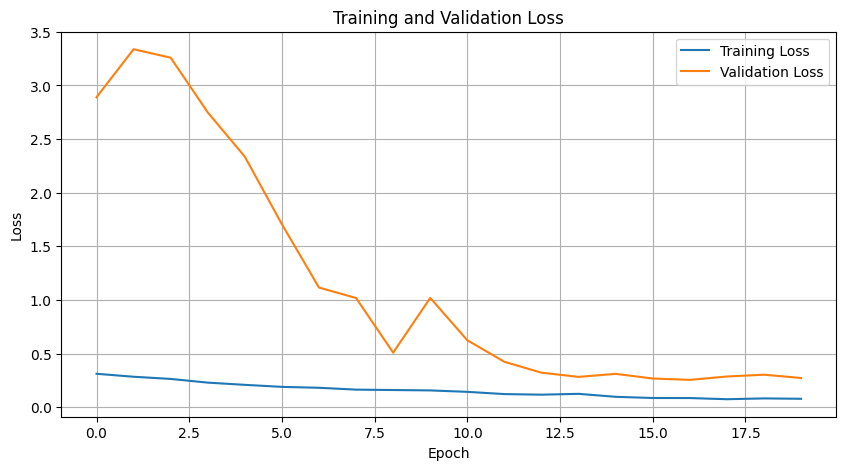

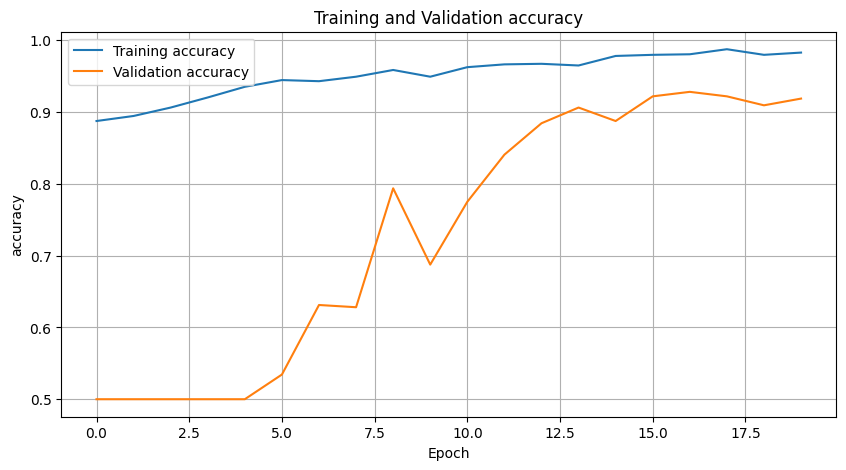

In [163]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.title("Training and Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Step 14: Evaluate the model on the test set

Now we measure how well the trained CNN performs on completely unseen test data.

In [198]:
results = model.evaluate(X_test, y_test)

y_pred_prob = model.predict(X_test)
y_pred = y_pred_prob > best_t

report = classification_report(y_test, y_pred)
print(report)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8850 - auc: 0.9537 - loss: 0.3534 - precision: 0.9096 - recall: 0.8550
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
              precision    recall  f1-score   support

         0.0       0.87      0.91      0.89       200
         1.0       0.91      0.86      0.88       200

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



## Step 15: Make predictions

The model outputs probability distributions over the 10 classes.

We convert them into final predicted classes using `argmax`.

In [191]:
print("First 10 predicted labels:", y_pred[:10])
print("First 10 true labels:     ", y_test[:10])

First 10 predicted labels: [[ True]
 [ True]
 [ True]
 [False]
 [False]
 [False]
 [False]
 [False]
 [ True]
 [ True]]
First 10 true labels:      [1. 1. 1. 0. 0. 0. 0. 0. 1. 1.]


## Step 16: Classification report

The classification report shows:
- precision
- recall
- F1-score
- support

for each class.

In [192]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.87      0.91      0.89       200
         1.0       0.91      0.86      0.88       200

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



## Step 17: Confusion matrix

A confusion matrix helps us see:
- which classes are classified correctly
- which classes are confused with others

For MNIST, common confusions may happen between visually similar digits.

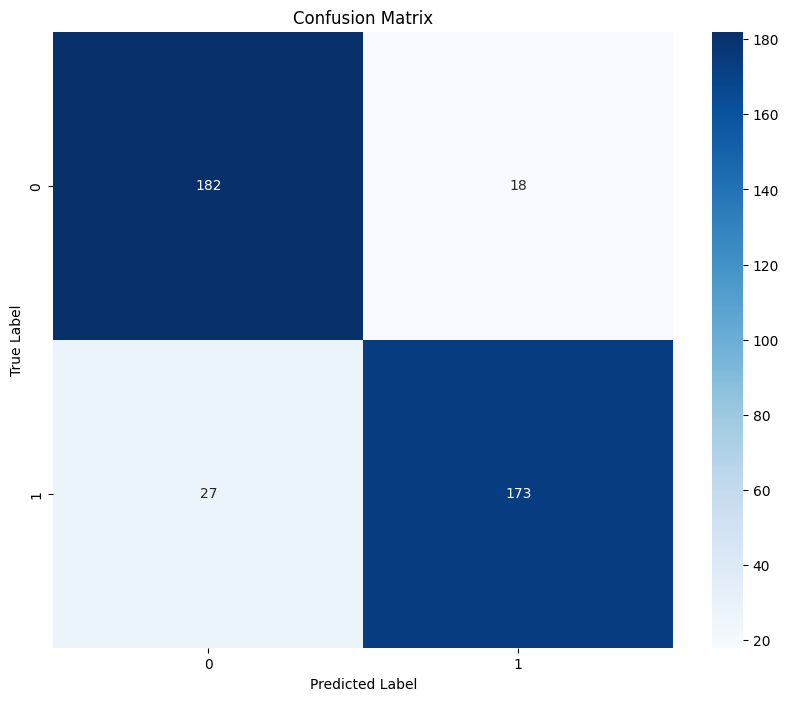

In [200]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Step 18: Visualize sample predictions

Let us display some test images along with:
- true label
- predicted label

This helps us inspect model behavior directly.

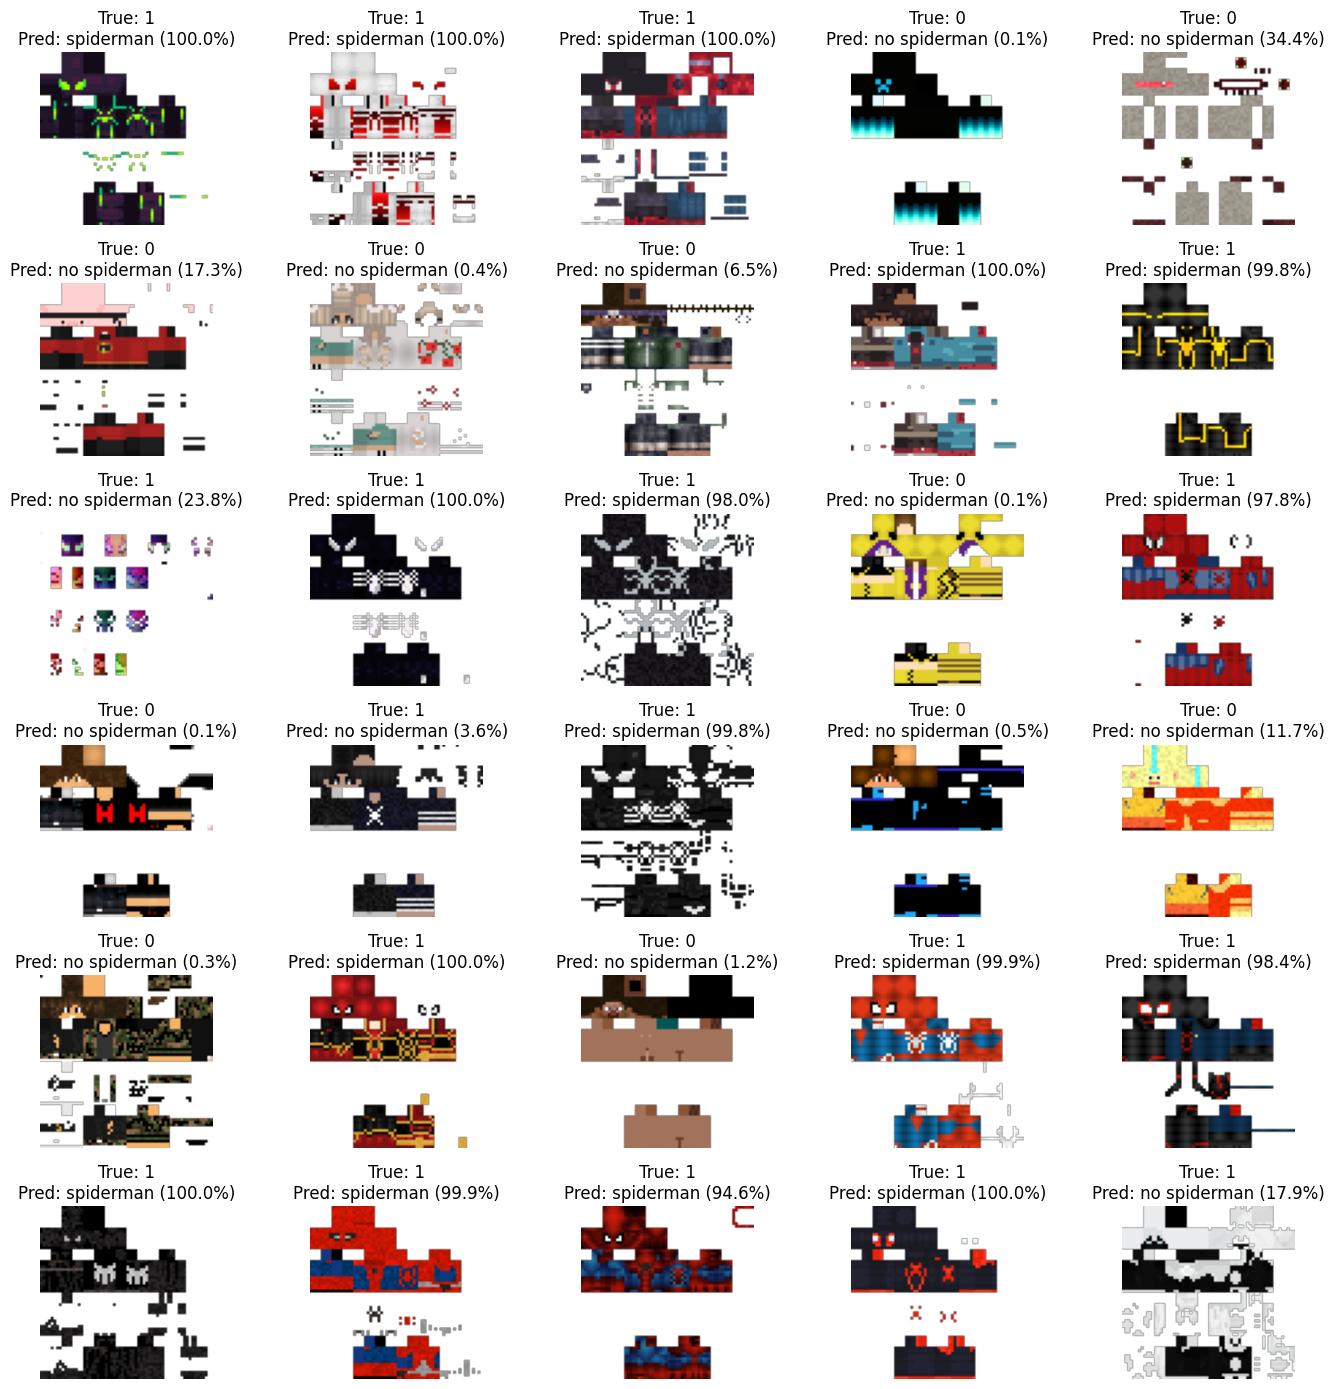

In [215]:
probs = np.asarray(y_pred_prob).ravel()              # shape (N,)
preds = (probs >= best_t).astype(int)                # or use 0.5 if you prefer fixed threshold

plt.figure(figsize=(14, 14))
for i in range(30):
    plt.subplot(6, 5, i + 1)
    plt.imshow(X_test[i])
    cls = "spiderman" if preds[i] == 1 else "no spiderman"
    plt.title(f"True: {int(y_test[i])}\nPred: {cls} ({probs[i]*100:.1f}%)")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Step 19: Show correct and incorrect predictions separately

This gives a better understanding of:
- where the model is strong
- where it makes mistakes

In [21]:
correct_indices = np.where(y_pred == y_test)[0]
incorrect_indices = np.where(y_pred != y_test)[0]

print("Number of correct predictions:", len(correct_indices))
print("Number of incorrect predictions:", len(incorrect_indices))

Number of correct predictions: 9871
Number of incorrect predictions: 129


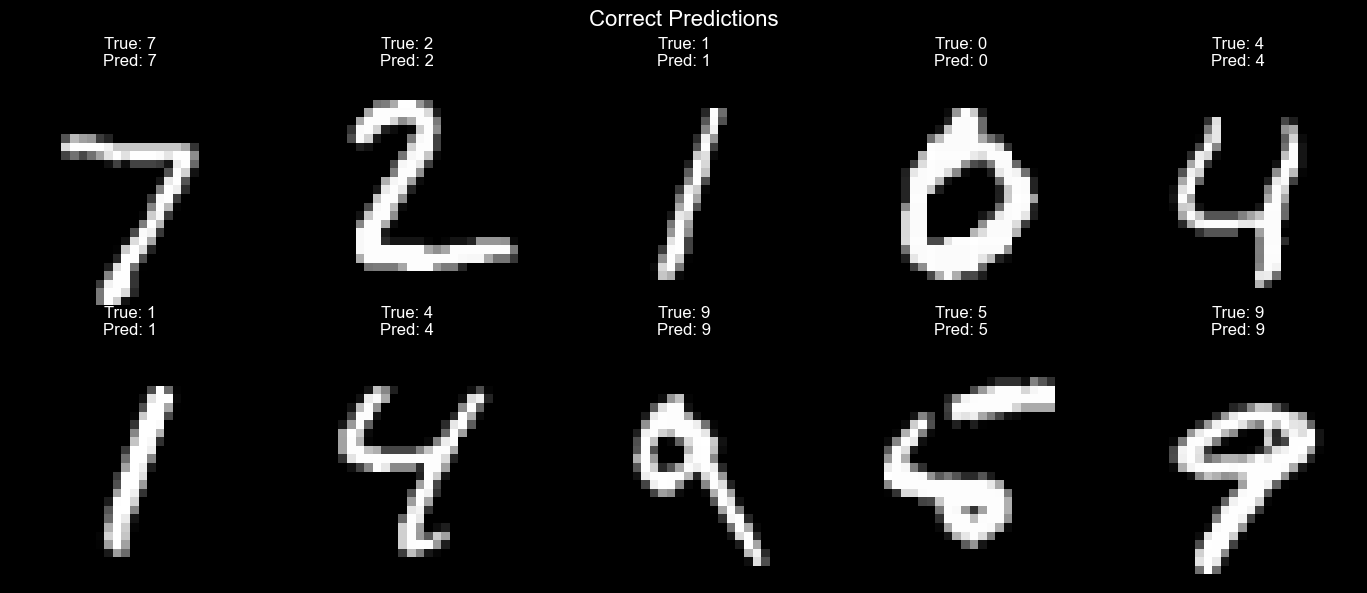

In [22]:
# Show some correct predictions
plt.figure(figsize=(14, 6))

for i, idx in enumerate(correct_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"True: {y_test[idx]}\nPred: {y_pred[idx]}")
    plt.axis("off")

plt.suptitle("Correct Predictions", fontsize=16)
plt.tight_layout()
plt.show()

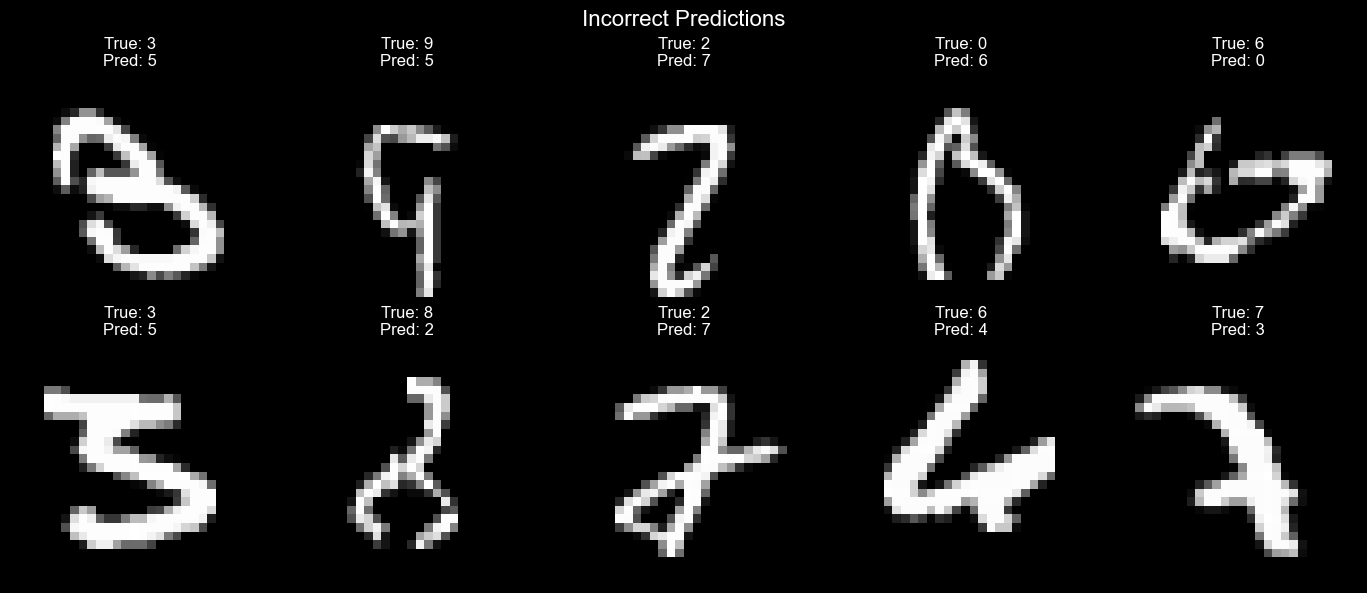

In [23]:
# Show some incorrect predictions
plt.figure(figsize=(14, 6))

for i, idx in enumerate(incorrect_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"True: {y_test[idx]}\nPred: {y_pred[idx]}")
    plt.axis("off")

plt.suptitle("Incorrect Predictions", fontsize=16)
plt.tight_layout()
plt.show()

## Step 20: Visualize prediction probabilities for a few images

This helps us understand the model’s confidence.

For each test image, we can plot the probabilities assigned to each digit class.

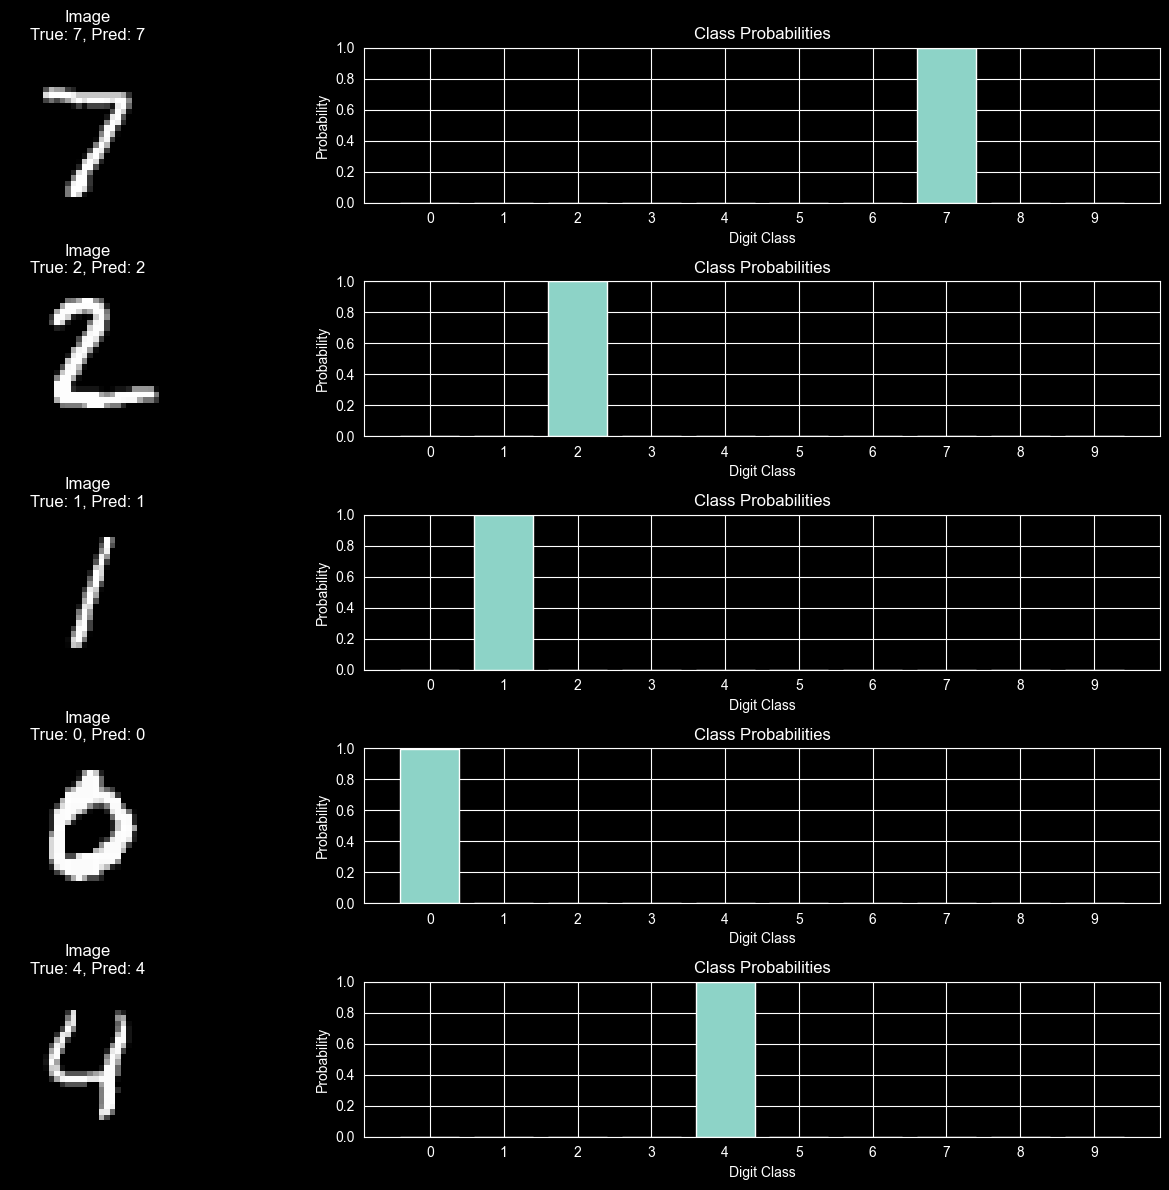

In [24]:
num_examples = 5
plt.figure(figsize=(15, 12))

for i in range(num_examples):
    # Image
    plt.subplot(num_examples, 2, 2*i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Image\nTrue: {y_test[i]}, Pred: {y_pred[i]}")
    plt.axis("off")
    
    # Probability bar chart
    plt.subplot(num_examples, 2, 2*i + 2)
    plt.bar(range(10), y_pred_probs[i])
    plt.xticks(range(10))
    plt.ylim(0, 1)
    plt.title("Class Probabilities")
    plt.xlabel("Digit Class")
    plt.ylabel("Probability")

plt.tight_layout()
plt.show()

## Step 21: Visualizing learned filters from the first convolution layer

The first convolution layer learns filters that detect basic patterns.

These filters are often somewhat interpretable and may respond to:
- edges
- strokes
- simple shapes

Since the input is grayscale, each filter is a small 3 × 3 matrix.

In [25]:
first_conv_layer = model.layers[0]
filters, biases = first_conv_layer.get_weights()

print("First conv layer name:", first_conv_layer.name)
print("Filter shape:", filters.shape)

First conv layer name: conv2d
Filter shape: (3, 3, 1, 32)


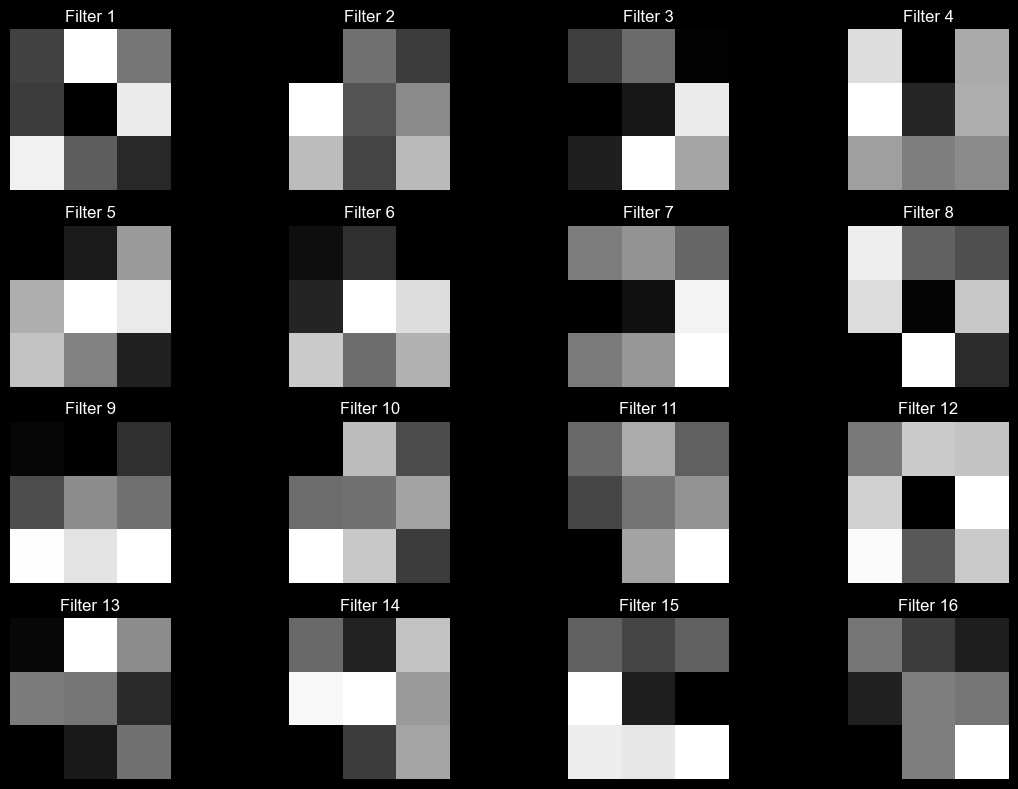

In [26]:
plt.figure(figsize=(12, 8))

for i in range(16):  # show first 16 filters
    f = filters[:, :, 0, i]
    
    plt.subplot(4, 4, i + 1)
    plt.imshow(f, cmap="gray")
    plt.title(f"Filter {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 22: Visualize feature maps

A feature map is the output produced when a filter scans over an image.

This lets us see what the CNN is "looking at" inside the image.

In [27]:
from tensorflow.keras.models import Model

# Make sure the model is built
_ = model.predict(X_test[:1], verbose=0)

# First convolution layer output
activation_model = Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

sample_image = X_test[0].reshape(1, 28, 28, 1)
feature_maps = activation_model.predict(sample_image, verbose=0)

print("Feature maps shape:", feature_maps.shape)

Feature maps shape: (1, 26, 26, 32)


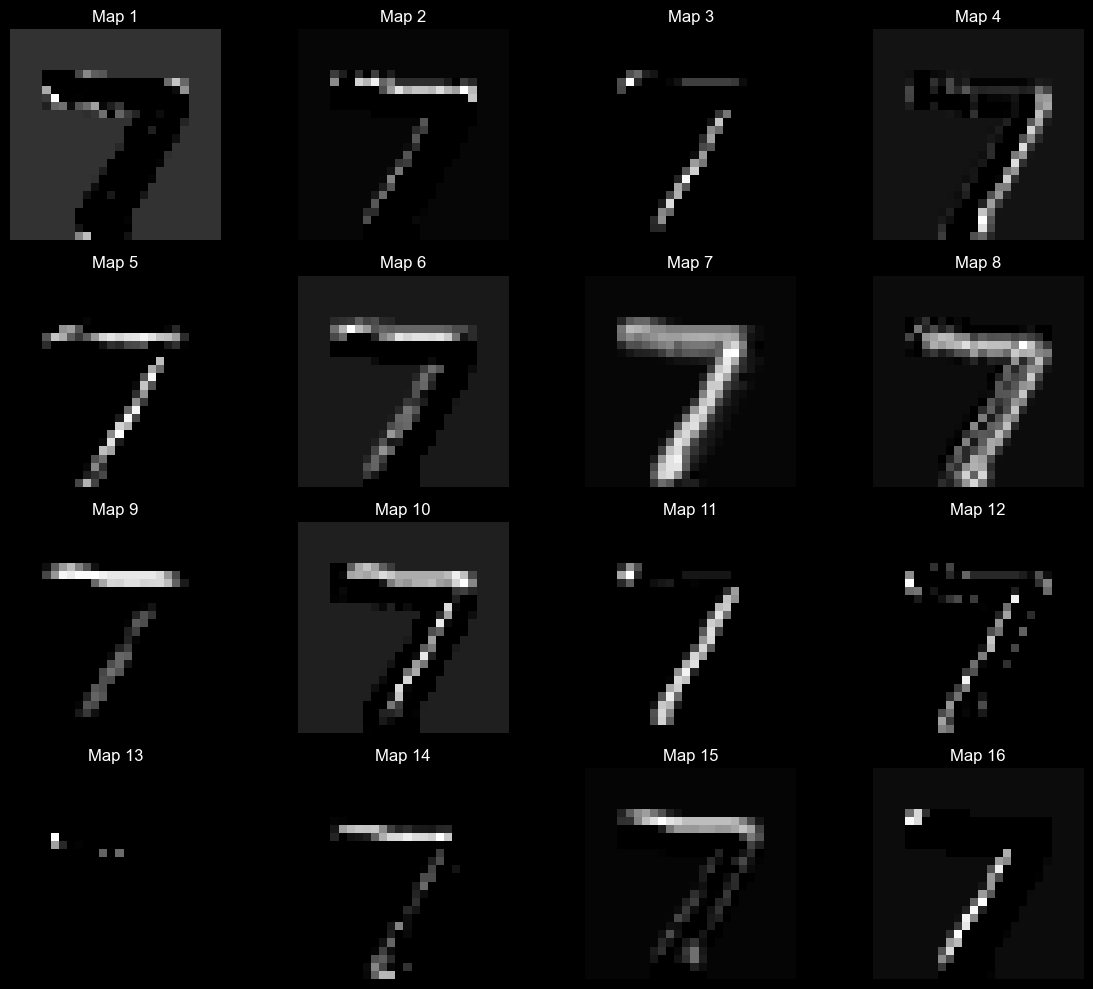

In [28]:
plt.figure(figsize=(12, 10))

for i in range(16):  # show first 16 feature maps
    plt.subplot(4, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap="gray")
    plt.title(f"Map {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 23: Key observations

After training the CNN, we typically observe:

1. The model learns quickly on MNIST
2. Accuracy becomes very high because MNIST is a well-structured dataset
3. The confusion matrix often shows only a small number of mistakes
4. Errors usually happen for visually similar digits
5. The convolutional layers learn useful low-level visual patterns

---

## Why CNN works well here

MNIST consists of images, and CNNs are designed specifically for image data.

They work well because they:
- exploit local spatial patterns
- reuse filters across the image
- build features hierarchically
- reduce the number of trainable parameters compared to large dense-only networks

## Step 24: Final conclusion

In this notebook, we built a complete CNN-based image classifier for the MNIST CSV dataset.

We learned how to:

- download a dataset from KaggleHub
- load CSV image data
- normalize pixel values
- reshape flat vectors into 2D image tensors
- one-hot encode labels
- build a CNN architecture
- train the CNN
- evaluate it on test data
- visualize training curves
- inspect confusion matrices
- examine correct and incorrect predictions
- view learned filters and feature maps

This is one of the most important practical foundations for learning deep learning and computer vision.

A CNN is much more suitable than a plain fully connected network for image classification because it preserves spatial structure and learns meaningful image features automatically.